In [10]:
import numpy as np
from numpy.fft import fft
import math
from scipy.signal import lfilter, stft
from scipy.stats import zscore
from scipy.io import wavfile
import matplotlib.pyplot as plt

Original audio shape: (248960,)
Cropped audio shape: (48320,)
(512, 300)


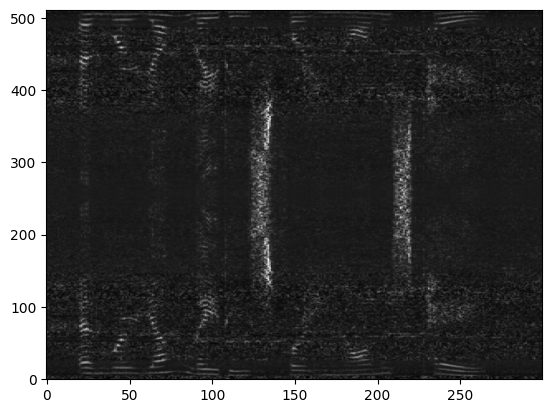

In [23]:
def rm_dc_n_dither(audio):
    """
    Remove DC offset and apply dithering to the audio signal.
    This function removes the DC offset from the input audio signal using a 
    high-pass filter and then applies dithering by adding a small amount of 
    noise to the signal.
    Args:
        audio (numpy.ndarray): Input audio signal as a numpy array.
    Returns:
        numpy.ndarray: Audio signal with DC offset removed and dithering applied.
    """
    # All files 16kHz tested..... Will copy for 8kHz from author's matlab code later
    alpha=0.99
    b=[1,-1]
    a=[1,-alpha]
    
    audio=lfilter(b,a,audio)
    
    dither=np.random.uniform(low=-1,high=1, size=audio.shape)
    spow=np.std(audio)
    return audio+(1e-6*spow)*dither

def preemphasis(audio, alpha=0.97):
    """
    Apply a pre-emphasis filter to the input audio signal.

    Parameters:
    audio (array-like): The input audio signal to be filtered.
    alpha (float, optional): The pre-emphasis coefficient. Default is 0.97.

    Returns:
    array-like: The filtered audio signal.
    """
    b=[1, -alpha]
    a=1
    return lfilter(b, a, audio)

def normalize_frames(m, epsilon=1e-12):
    """
    Normalize the frames of a given matrix.

    This function normalizes each frame (row) of the input matrix `m` by 
    subtracting the mean and dividing by the standard deviation. The standard
    deviation is clipped to a minimum value of `epsilon` to avoid division by zero.

    Parameters:
    m (numpy.ndarray): The input matrix where each row represents a frame to 
    be normalized.
    epsilon (float, optional): A small value to avoid division by zero. 
    Default is 1e-12.

    Returns:
    numpy.ndarray: The normalized matrix with the same shape as the input.
    """
    return (m-m.mean(1, keepdims=True))/np.clip(m.std(1, keepdims=True),epsilon, None)

def preprocess(audio, buckets=None, sr=16000, Ws=25, Ss=10, alpha=0.97):
    """
    Preprocesses the given audio signal to generate a spectrogram.
    Parameters:
    audio (numpy.ndarray): The input audio signal.
    buckets (dict, optional): A dictionary mapping frame sizes to bucket sizes. 
    Default is None.
    sr (int, optional): The sample rate of the audio signal. Default is 16000.
    Ws (int, optional): The window size in milliseconds. Default is 25.
    Ss (int, optional): The step size in milliseconds. Default is 10.
    alpha (float, optional): The preemphasis filter coefficient. Default is 0.97.
    Returns:
    numpy.ndarray: The preprocessed spectrogram of the audio signal.
    """
    #ms to number of frames
    if not buckets:
        buckets={100: 2,
             200: 5,
             300: 8,
             400: 11,
             500: 14,
             600: 17,
             700: 20,
             800: 23,
             900: 27,
             1000: 30}
    
    # Nw and Ns in samples
    # Nw is window size in samples
    # Ns is step size in samples
    Nw = round((Ws*sr)/1000)  
    Ns = round((Ss*sr)/1000)
    
    # hamming window func signature
    window = np.hamming
    # get next power of 2 greater than or equal to current Nw
    nfft = 1<<(Nw-1).bit_length()
    
    # Remove DC and add small dither
    audio = rm_dc_n_dither(audio)
    
    # Preemphasis filtering
    audio = preemphasis(audio, alpha)
    
    
    #get 512x300 spectrograms
    _, _, mag = stft(audio,
    fs=sr, 
    window=window(Nw), 
    nperseg=Nw, 
    noverlap=Nw-Ns, 
    nfft=nfft, 
    return_onesided=False, 
    padded=False, 
    boundary=None)

    mag = normalize_frames(np.abs(mag))
    
    # Get the largest bucket smaller than number of column vectors i.e. frames
    rsize = max(i for i in buckets if i<=mag.shape[1])
    rstart = (mag.shape[1]-rsize)//2
    # Return truncated spectrograms
    return mag[:,rstart:rstart+rsize]


if __name__=="__main__":
    # Test file same as one on the authors github for testing and maintaining consistency
    # sr, audio = wavfile.read("test.wav")
    # sr, audio = wavfile.read("samples/speech/Speech-Media1.wav")
    sr, audio = wavfile.read("samples/mixed/Media1.wav")
    buckets={100: 2,
     200: 5,
     300: 8,
     400: 11,
     500: 14,
     600: 17,
     700: 20,
     800: 23,
     900: 27,
     1000: 30}
    print('Original audio shape:', audio.shape)
    # Crop and pass 3s audio for preprocessing
    audio = audio[:48320]
    print('Cropped audio shape:', audio.shape)
    pp = preprocess(audio, buckets)
    print(pp.shape)

    # Save the preprocessed spectrogram as an image file for viewing
    plt.imshow(pp, aspect='auto', origin='lower', cmap='gray')
    plt.savefig("test.png")
    plt.show()

    


In [27]:
# Create a Confusion matrix

# True Positives (TP): Correctly identified enrolled speakers.
# False Negatives (FN): Enrolled speakers that were incorrectly identified as unenrolled.
# True Negatives (TN): Correctly identified unenrolled speakers.
# False Positives (FP): Unenrolled speakers that were incorrectly identified as enrolled.

# Some sample code to create a confusion matrix
from sklearn.metrics import confusion_matrix

true_positives = 2
true_negatives = 2
false_positives = 1
false_negatives = 1

confusion_matrix = np.array([[true_positives, false_positives],\
                                [false_negatives, true_negatives]])
print(confusion_matrix)

# Output
# create a confusion matrix
# array([[2, 0, 0],
#        [0, 0, 1],
#        [1, 0, 2]])

# The confusion matrix above shows that there are 2 true positives, 1 false positive, and 1 false negative.
# The true negatives are not shown in the matrix because they are not part of the prediction task.
# The matrix is a 3x3 array where the rows represent the true labels and the columns represent the predicted labels.
# The diagonal elements of the matrix represent the true positives, while the off-diagonal elements represent the false positives and false negatives.

# The confusion matrix can be used to calculate various performance metrics such as accuracy, precision, recall, and F1 score.
# These metrics can help evaluate the performance of a classification model and identify areas for improvement.

# Calculate accuracy, precision, recall, and F1 score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
y_true = [2, 0, 2, 2, 0, 1]
y_pred = [0, 0, 2, 2, 0, 2]
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
false_positive_rate = 1 - precision
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)
print('False Positive Rate:', false_positive_rate)


[[2 1]
 [1 2]]
Accuracy: 0.6666666666666666
Precision: 0.4444444444444444
Recall: 0.5555555555555555
F1 Score: 0.48888888888888893
False Positive Rate: 0.5555555555555556


c:\tools\python_envs\pytorch_env\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [32]:
import torch
import torch.nn as nn

# Example of target with class indices
loss = nn.CrossEntropyLoss()
input = torch.randn(3, 5, requires_grad=True)
target = torch.empty(3, dtype=torch.long).random_(5)
output = loss(input, target)
output.backward()

# Example of target with class probabilities
input = torch.randn(3, 5, requires_grad=True)
target = torch.randn(3, 5).softmax(dim=1)
output = loss(input, target)
output.backward()

AttributeError: partially initialized module 'torch' has no attribute 'types' (most likely due to a circular import)